# From ordinary GAD to competitive-subspace GAD

<div style="padding: 0.8em 1em; border-left: 5px solid #0072B2; background: #F3F8FB">
<b>Purpose.</b> This notebook is a five-minute visual explanation of the method evolution. It is a fully analytic toy: no molecule, learned potential, optimizer history, or hidden rescue rule.
</div>

We use a four-well potential because it contains both things a saddle search must distinguish:

- four stable basins and index-1 edge saddles;
- an index-2 central region, where ordinary one-mode GAD has no globalization mechanism.

We then add the small near-degenerate soft-subspace diagnostic that motivates the final g-xTB refinement.

## The progression in one line

| Stage | Local rule | Why it was introduced |
|---|---|---|
| Ordinary GAD | Always reverse the softest component. | Makes an index-1 saddle locally attracting. |
| Hard index gate | Descend for \(\lambda_2<0\), otherwise GAD. | Prevents ascent inside a clear high-index region. |
| Smooth \(\lambda_2\) gate | Replace the switch by \(w_2=\sigma[\lambda_2/(\tau s_H)]\). | The LJ7 globalization fix: no discontinuous index branch. |
| Competitive gate | Turn ascent on early only when soft-mode gradient activity dominates activity in the other negative modes. | Addresses molecular minimum capture. |
| Competitive-subspace | Use relative soft weights in the reflection. | Prevents a near-degenerate soft density from diluting the reflection. |

Every version below is a function only of the **current** \(q\), \(\nabla E(q)\), and \(\nabla^2E(q)\).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams.update({
    "figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 10,
})

ALPHA = 0.90  # a tiny symmetry-breaking anisotropy

ALPHA = 0.90  # a tiny symmetry-breaking anisotropy

COLORS = {"ordinary": "#7F7F7F", "lambda2": "#CC79A7", "competitive": "#0072B2", "subspace": "#009E73"}

## 1. An exact four-well landscape

$$
E(x,y)=(x^2-1)^2+0.9(y^2-1)^2.
$$

The origin has two negative Hessian eigenvalues. The points \((0,\pm1)\) and \((\pm1,0)\) are index-1 saddles. The four corners are minima. The slight anisotropy removes an unhelpful exact symmetry while preserving the four-well/index-two topology.

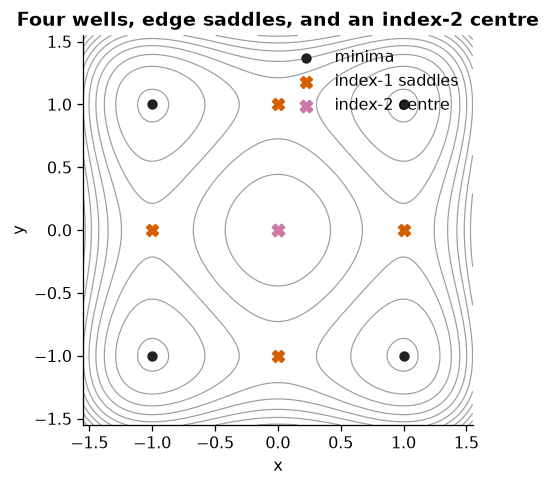

In [2]:
def E(q):
    x, y = q
    return (x*x - 1)**2 + ALPHA*(y*y - 1)**2

def grad(q):
    x, y = q
    return np.array([4*x*(x*x - 1), 4*ALPHA*y*(y*y - 1)], dtype=float)

def hess(q):
    x, y = q
    return np.diag([12*x*x - 4, ALPHA*(12*y*y - 4)])

grid = np.linspace(-1.55, 1.55, 300)
X, Y = np.meshgrid(grid, grid)
Z = (X*X - 1)**2 + ALPHA*(Y*Y - 1)**2
fig, ax = plt.subplots(figsize=(5.1, 4.4))
ax.contour(X, Y, Z, levels=np.linspace(0.06, 5.0, 14), colors="#9E9E9E", linewidths=.75)
ax.scatter([-1, -1, 1, 1], [-1, 1, -1, 1], c="#222222", s=30, label="minima")
ax.scatter([0, 0, -1, 1], [-1, 1, 0, 0], c="#D55E00", marker="X", s=55, label="index-1 saddles")
ax.scatter([0], [0], c="#CC79A7", marker="X", s=60, label="index-2 centre")
ax.set(xlim=(-1.55, 1.55), ylim=(-1.55, 1.55), aspect="equal", xlabel="x", ylabel="y", title="Four wells, edge saddles, and an index-2 centre")
ax.legend(frameon=False, loc="upper right"); plt.show()

## 2. One common closed-form local step

Diagonalize the current Hessian, \(H=U\Lambda U^T\), and write \(c=U^Tg\). The whole family uses

$$
b_i=(1-2w r_i)c_i,\qquad
\mu=\frac{\|b\|}{R},\qquad
a_i=-\frac{b_i}{\sqrt{\lambda_i^2+\mu^2}},\qquad
q^+=q+Ua.
$$

The toy uses a fixed display radius \(R\). The real method replaces it with the intrinsic, current-geometry pair-distance radius. The difference between methods is only the scalar gate \(w\) and reflection weights \(r_i\).

In [3]:
def sigmoid(z):
    return 1/(1 + np.exp(-np.clip(z, -60, 60)))

@dataclass(frozen=True)
class Policy:
    name: str
    key: str
    competitive: bool = False
    subspace: bool = False

POLICIES = (
    Policy("ordinary GAD", "ordinary"),
    Policy(r"smooth $\lambda_2$ gate", "lambda2"),
    Policy("competitive gate", "competitive", competitive=True),
    Policy("competitive-subspace", "subspace", competitive=True, subspace=True),
)

def local_quantities(q, tau=.18):
    lam, U = np.linalg.eigh(hess(q))
    c = U.T @ grad(q)
    sH = max(np.sqrt(np.mean(lam**2)), 1e-12)
    z = lam/(tau*sH)
    p = np.exp(-z - np.max(-z)); p /= p.sum()               # soft-min density
    neg = sigmoid(-z)                                        # smooth negative-subspace mask
    w2 = sigmoid(z[1])                                       # smooth lambda_2 gate
    Asoft = np.sum(p*c**2)
    Aextra = np.sum(neg*(1-p)**2*c**2)
    chi = Asoft/(Asoft + Aextra) if Asoft + Aextra > 0 else 0.
    return lam, U, c, p, w2, chi

def step(q, policy, R=.085, tau=.18):
    lam, U, c, p, w2, chi = local_quantities(q, tau)
    if policy.key == "ordinary":
        w, r = 1., np.array([1., 0.])
    else:
        w = w2 + (1-w2)*chi if policy.competitive else w2
        r = p/p.max() if policy.subspace else p
    b = (1 - 2*w*r)*c
    mu = np.linalg.norm(b)/R if np.linalg.norm(b) > 0 else 1.
    return U @ (-b/np.sqrt(lam**2 + mu**2)), {"lambda": lam, "p": p, "w2": w2, "chi": chi, "w": w, "r": r}

def trace(start, policy, n=220, tau=.18, R=.085):
    path = [np.array(start, dtype=float)]
    for _ in range(n): path.append(path[-1] + step(path[-1], policy, R=R, tau=tau)[0])
    return np.array(path)

## 3. A controlled contrast: competitive GAD avoids a minimum capture

The following start is deliberately chosen to expose the distinction between the two **smooth** policies. With the same local radius and a fixed 200-step budget, the smooth \(\lambda_2\) gate spends too long in descent and becomes force-small in the nearby minimum. The competitive rule detects that the soft direction carries the useful local activity and turns on its ascent component early enough to reach the adjacent index-1 saddle.

This is an **illustration of mechanism**, not a statistical benchmark. Ordinary GAD also succeeds on this low-dimensional surface; that is why LJ7 and the g-xTB matched grid remain necessary validation tests.

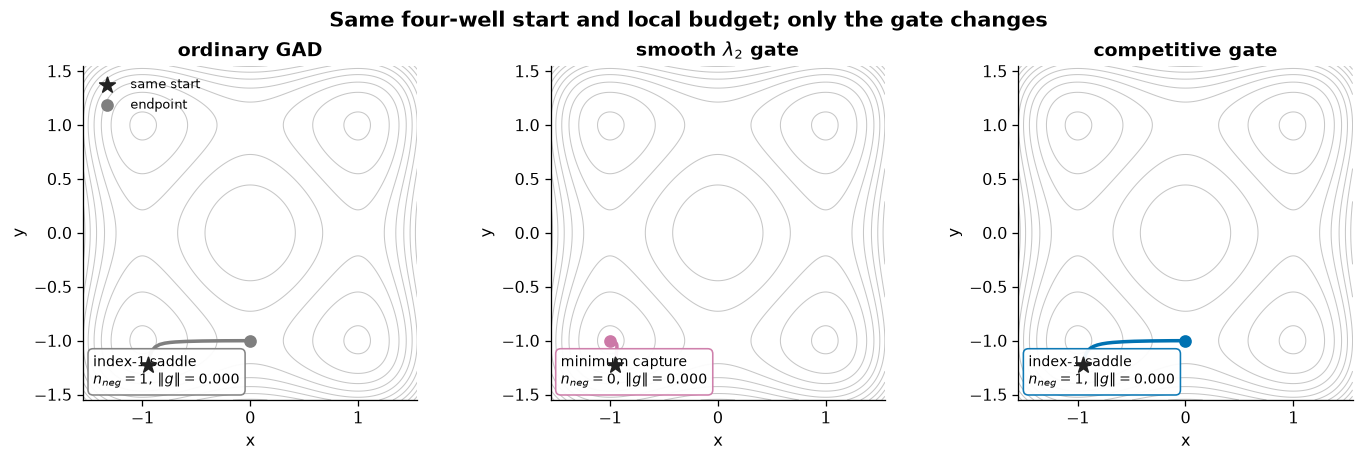

In [4]:
selected_start = np.array([-0.95, -1.23])
selected_policies = POLICIES[:3]  # ordinary, lambda2, competitive
tau, R, budget = .70, .05, 200

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.9), constrained_layout=True)
for ax, policy in zip(axes, selected_policies):
    path = trace(selected_start, policy, n=budget, tau=tau, R=R)
    endpoint = path[-1]
    eigenvalues = np.linalg.eigvalsh(hess(endpoint))
    index = int(np.sum(eigenvalues < -1e-8))
    force = np.linalg.norm(grad(endpoint))
    ax.contour(X, Y, Z, levels=np.linspace(.06, 5., 14), colors="#C7C7C7", linewidths=.65)
    ax.plot(path[:, 0], path[:, 1], lw=2.2, color=COLORS[policy.key])
    ax.scatter(*selected_start, marker="*", s=105, color="#222222", zorder=4, label="same start")
    ax.scatter(*endpoint, s=48, color=COLORS[policy.key], zorder=5, label="endpoint")
    outcome = "index-1 saddle" if index == 1 and force < .05 else "minimum capture" if index == 0 and force < .05 else "not converged"
    ax.set(title=policy.name, xlim=(-1.55, 1.55), ylim=(-1.55, 1.55), aspect="equal", xlabel="x", ylabel="y")
    ax.text(.03, .03, f"{outcome}\n$n_{{neg}}={index}$, $\\|g\\|={force:.3f}$", transform=ax.transAxes,
            va="bottom", ha="left", fontsize=9, bbox={"boxstyle": "round,pad=.35", "fc": "white", "ec": COLORS[policy.key], "alpha": .94})
axes[0].legend(frameon=False, loc="upper left", fontsize=8)
fig.suptitle("Same four-well start and local budget; only the gate changes", fontsize=13, fontweight="bold")
plt.show()

## 4. The final addition: why a relative soft subspace?

For the g-xTB rule, the scalar competitive gate is

$$
w=w_2+(1-w_2)\chi,\quad
\chi=\frac{A_{\rm soft}}{A_{\rm soft}+A_{\rm extra}},
$$

where \(A_{\rm extra}\) counts activity only in additional negative-curvature directions. The final change is **not** a new gate. It changes only the reflection density:

$$
r_i=p_i \quad\longrightarrow\quad \widetilde p_i=\frac{p_i}{\max_jp_j}.
$$

Near a degenerate soft spectrum, normalized \(p_1\) is below one, which weakens the rank-one multiplier \(1-2wp_1\). The relative density restores a full reflection of the lowest soft subspace.

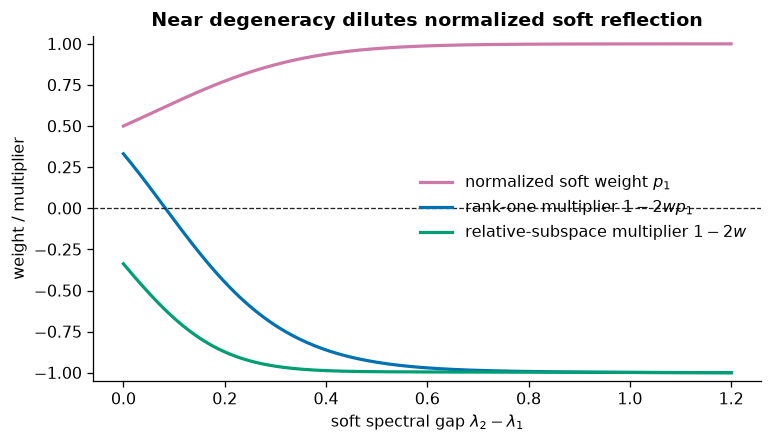

In [5]:
gaps = np.linspace(0, 1.2, 240)
p1, rank_one, relative = [], [], []
for gap in gaps:
    # A two-mode local spectrum with soft-mode-dominated gradient activity.
    lam = np.array([-1., -1.+gap]); sH = np.sqrt(np.mean(lam**2)); z = lam/(.18*sH)
    p = np.exp(-z-np.max(-z)); p /= p.sum()
    c = np.array([1., .05]); neg = sigmoid(-z); w2 = sigmoid(z[1])
    chi = np.sum(p*c*c)/(np.sum(p*c*c)+np.sum(neg*(1-p)**2*c*c))
    w = w2 + (1-w2)*chi
    p1.append(p[0]); rank_one.append(1-2*w*p[0]); relative.append(1-2*w)

fig, ax = plt.subplots(figsize=(7.5,3.9))
ax.plot(gaps,p1,color="#CC79A7",lw=2,label=r"normalized soft weight $p_1$")
ax.plot(gaps,rank_one,color="#0072B2",lw=2,label=r"rank-one multiplier $1-2wp_1$")
ax.plot(gaps,relative,color="#009E73",lw=2,label=r"relative-subspace multiplier $1-2w$")
ax.axhline(0,color="#222222",ls="--",lw=.8)
ax.set(xlabel=r"soft spectral gap $\lambda_2-\lambda_1$",ylabel="weight / multiplier",ylim=(-1.05,1.05),title="Near degeneracy dilutes normalized soft reflection")
ax.legend(frameon=False,ncol=1); plt.show()

## Takeaway

<div style="padding: 0.8em 1em; border-left: 5px solid #009E73; background: #F3FBF7">
<b>Final method.</b> Competitive-subspace GAD retains the LJ smooth \(\lambda_2\) high-index descent phase, uses the current local gradient to avoid premature ascent in molecular high-index regions, and makes the soft reflection robust to near-degenerate low modes. It remains a bounded, deterministic second-order local map.
</div>

The full mass-weighted/Eckart derivation, scale covariance, and Transition1x/g-xTB results are in `docs/POINTWISE_INTRINSIC_GAD.md`.